# Аугментация изображений

Нейросети учатся лучше когда видят данные в разных вариантах. Аугментация - способ создать больше вариантов из одного изображения без загрузки больших датасетов.

## Библиотеки

In [13]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}, Torchvision: {torchvision.__version__}')

PyTorch: 2.9.1+cu128, Torchvision: 0.24.1+cu128


## Синтетическое изображение

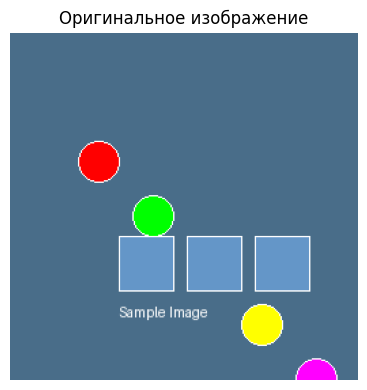

In [14]:
img = Image.new('RGB', (256, 256), color=(73, 109, 137))
draw = ImageDraw.Draw(img)

for i, color in enumerate([(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]):
    x = 50 + i * 40
    draw.ellipse([x, x + 30, x + 30, x + 60], fill=color, outline=(255, 255, 255))

for i in range(3):
    x = 80 + i * 50
    draw.rectangle([x, 150, x + 40, 190], fill=(100, 150, 200), outline=(255, 255, 255))

draw.text((80, 200), 'Sample Image', fill=(255, 255, 255))

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title('Оригинальное изображение')
plt.axis('off')
plt.tight_layout()
plt.show()

## Аугментации

1. **RandomHorizontalFlip** - зеркальное отражение
2. **ColorJitter** - меняем яркость и контраст
3. **RandomRotation** - поворачиваем на ±30°
4. **RandomAffine** - смещение, масштаб, поворот
5. **GaussianBlur** - размытие

## Реализация пайплайна аугментаций


In [15]:
augmentations = {
    'RandomHorizontalFlip': transforms.RandomHorizontalFlip(p=0.5),
    'ColorJitter': transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    'RandomRotation': transforms.RandomRotation(degrees=30),
    'RandomAffine': transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    'GaussianBlur': transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
}

## Каждая аугментация отдельно

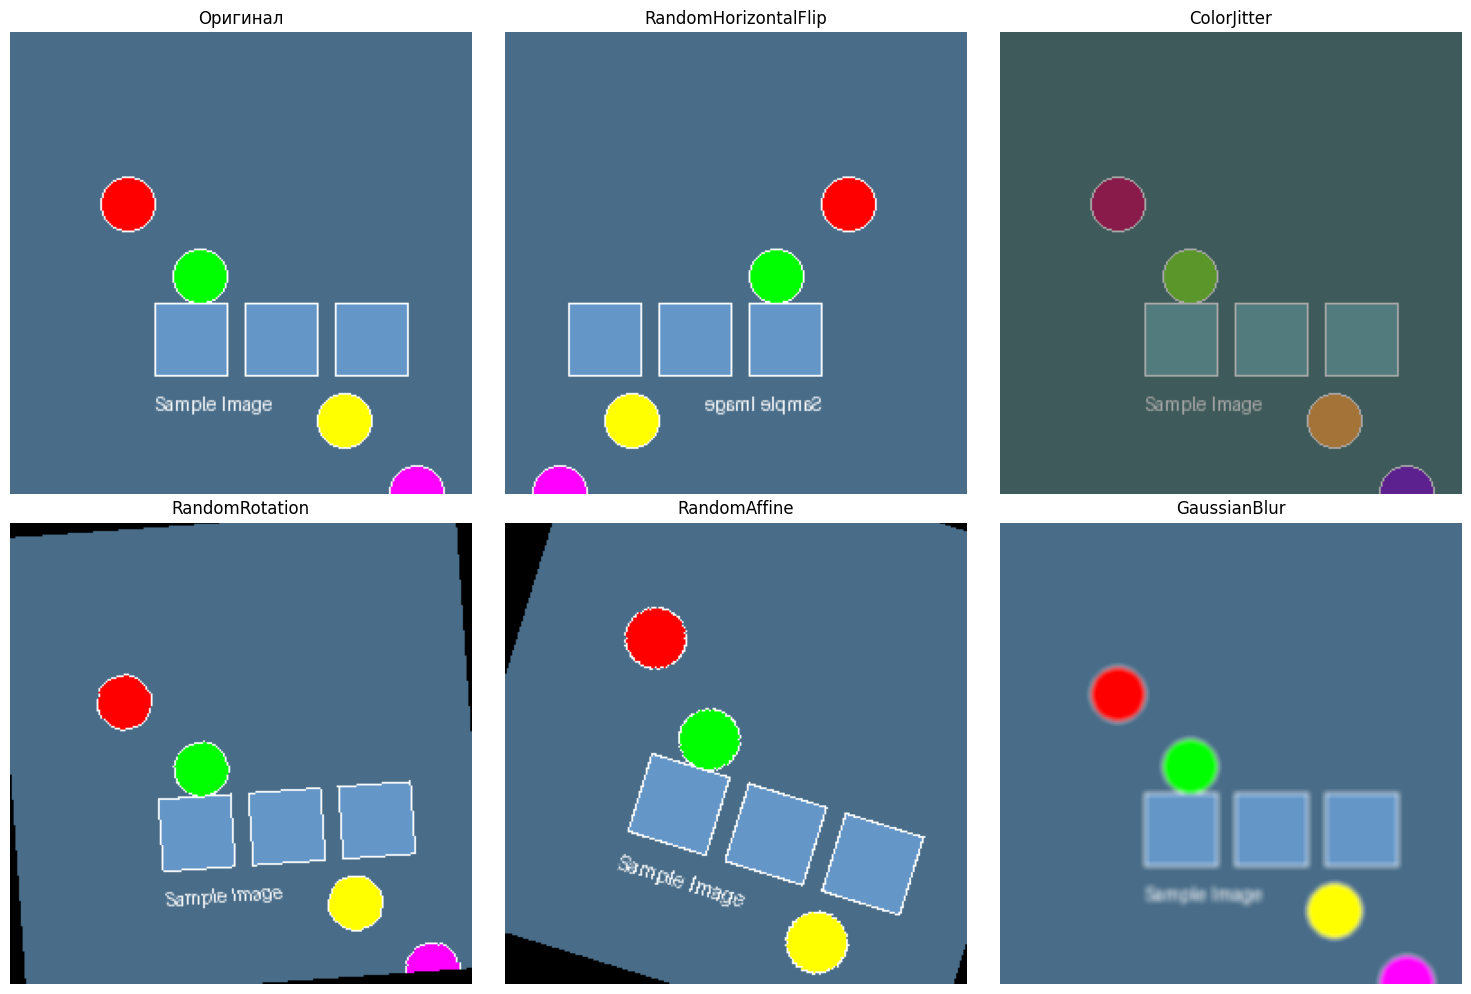

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(img)
axes[0].set_title('Оригинал')
axes[0].axis('off')

for idx, (name, transform) in enumerate(augmentations.items(), start=1):
    axes[idx].imshow(transform(img))
    axes[idx].set_title(name)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Все аугментации вместе

In [17]:
pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
])

## 10 вариантов одного изображения

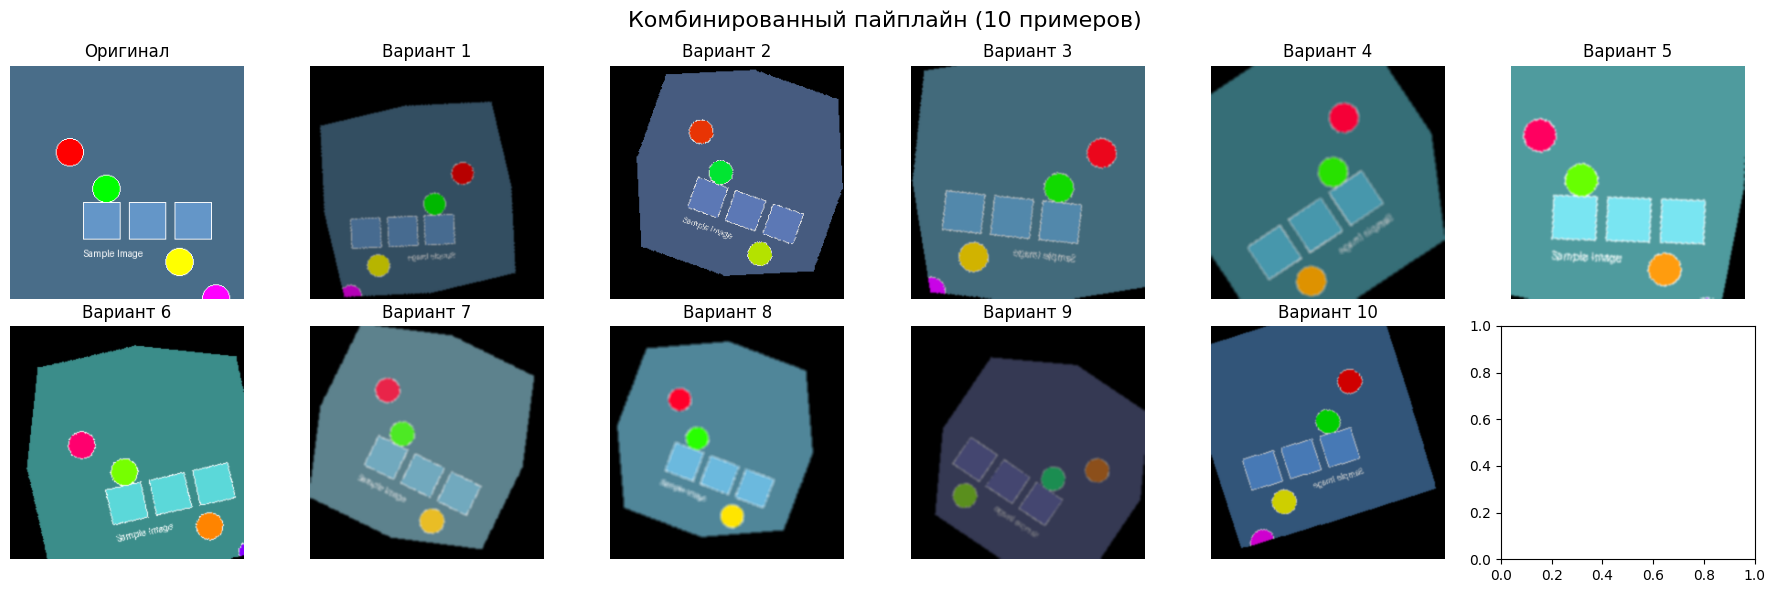

In [18]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

axes[0].imshow(img)
axes[0].set_title('Оригинал')
axes[0].axis('off')

for i in range(1, 11):
    axes[i].imshow(pipeline(img))
    axes[i].set_title(f'Вариант {i}')
    axes[i].axis('off')

plt.suptitle('Комбинированный пайплайн (10 примеров)', fontsize=16)
plt.tight_layout()
plt.show()

## Анализ

| Трансформация | Описание | Зачем |
|---|---|---|
| RandomHorizontalFlip | Отражение | Объекты одинаковые в зеркале |
| ColorJitter | Цвета | Модель независима от освещения |
| RandomRotation | Поворот ±30° | Инвариантность к ориентации |
| RandomAffine | Смещение+масштаб | Объект может быть где угодно |
| GaussianBlur | Размытие | Смотрим на общую картину |

## Итоги

- Из 1000 изображений делаем 5000-10000 вариантов
- RandomHorizontalFlip для цифр - плохо (6 -> 9)
- Для каждой задачи - свои трансформации